# Финальное задание
## Текст задания

Задача:
Обучить Stable Diffusion на стиль или объект/персонаж.
Датасет: 10–200 изображений (1:1, хорошее качество).
Сгенерировать серию изображений.
Оформить лонгрид на hsedesign.ru.

Результаты:
Код обучения (.ipynb).
Исходные изображения.
Серия сгенерированных изображений + комментарии.
Описание идеи проекта.
Раздел про использование ИИ (если применяли).

Критерии:
Консистентность стиля, передача особенностей объекта.
Презентация, оригинальность.

Сдача:
Загрузить проект на сайте курса через «Загрузить проект».

### Идея
Мой проект посвящен повторению bubble design. Хотелось создать нейросетевую модель, которая понимает не только форму шара, но и специфику материалов, те же блики на пластике, мягкие тени и градиенты.

В качестве датасета было собрано 30 изображений от 3D-букв до абстрактных надувных скульптур логотипов.

Для обучения использовалась технология LoRA на базе модели Stable Diffusion v1.5. ИИ позволил переносить саму логику объема на любые новые запросы — от архитектуры до типографики

In [2]:
# Установка необходимых библиотек (используем diffusers от Hugging Face)
!pip install -q diffusers transformers accelerate bitsandbytes xformers ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00


Возник конфликт версий, так как постоянно выпукаются новые состояния библиотек питона, а потом очень долго пытаются возобновить совместимость

In [6]:
# Удаляем старую версию и ставим из исходников + нужные зависимости
!pip uninstall -y diffusers
!pip install git+https://github.com/huggingface/diffusers
!pip install -q transformers accelerate bitsandbytes xformers ftfy

Found existing installation: diffusers 0.37.0
Uninstalling diffusers-0.37.0:
  Successfully uninstalled diffusers-0.37.0
  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-e3_xs85w
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-e3_xs85w
  Resolved https://github.com/huggingface/diffusers to commit b9761ce5a2b8bc49fb218d8254e9e609fae144a6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.38.0.dev0-py3-none-any.whl size=5071511 sha256=312f50736dfdfc000a618273709d7c09a963ef3779fc53062203b2aba50daea1
  Stored in directory: /tmp/pip-ephem-wheel-cache-hw8ffcax/wheels/90/d4/44/a58bc00fb405fefb633b0d9d2307f6e3aec6cc1775d82555d3
Successfully built diffusers


In [3]:
# Клонируем репозиторий с кодом для обучения
!git clone https://github.com/huggingface/diffusers.git

Cloning into 'diffusers'...
remote: Enumerating objects: 118588, done.
remote: Counting objects: 100% (551/551), done.
remote: Compressing objects: 100% (316/316), done.
remote: Total 118588 (delta 453), reused 235 (delta 235), pack-reused 118037 (from 4)
Receiving objects: 100% (118588/118588), 91.53 MiB | 22.98 MiB/s, done.
Resolving deltas: 100% (88593/88593), done.


In [4]:
import os

DATA_DIR = "/content/bubble_dataset"
OUTPUT_DIR = "/content/bubble_model_output"

# Создаем папки
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [7]:
# Параметры самой модели будут по умолчанию
MODEL_NAME = "runwayml/stable-diffusion-v1-5"
INSTANCE_PROMPT = "bubblestyle" # Короткий триггер для промптов модельки

!accelerate launch diffusers/examples/dreambooth/train_dreambooth_lora.py \
  --pretrained_model_name_or_path=$MODEL_NAME \
  --instance_data_dir=$DATA_DIR \
  --output_dir=$OUTPUT_DIR \
  --instance_prompt="$INSTANCE_PROMPT" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --checkpointing_steps=500 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=500 \
  --seed=42

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
tokenizer_config.json: 100% 806/806 [00:00<00:00, 3.76MB/s]
vocab.json: 1.06MB [00:00, 27.3MB/s]
merges.txt: 525kB [00:00, 101MB/s]
special_tokens_map.json: 100% 472/472 [00:00<00:00, 2.76MB/s]
config.json: 100% 617/617 [00:00<00:00, 3.68MB/s]
You are using a model of type clip_text_model to instantiate a model of typ

In [8]:
from diffusers import DiffusionPipeline
import torch
from google.colab import files # Чтобы быстро скачать веса в конце, потому что в колабе всё удаляется при перезапуске среды

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [9]:
pipe = DiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to("cuda")
pipe.load_lora_weights(OUTPUT_DIR)
# Тестовый промпт
prompt = "a futuristic glossy chair, bubblestyle design, soft pink and mint colors, 4k"

image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
image.save("bubble_result.png")
# files.download(f"{OUTPUT_DIR}/pytorch_lora_weights.safetensors") # автоскачивание весов, чтобы заново не переносить

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/30 [00:00<?, ?it/s]

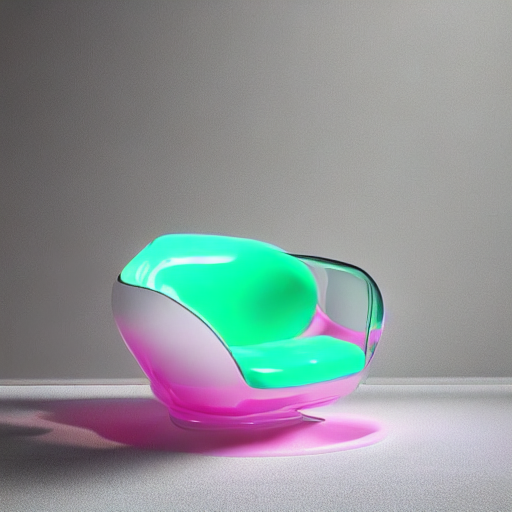

In [10]:
display(image)

Напишем ещё несколько промптов и запустим генерацию вновь)

In [11]:
prompt = "an apple ipod from 2005 but designed in bubblestyle, soft rounded contours, puffy buttons, chrome glossy finish, translucent pink plastic casing, soft 3d lighting, high detail"

In [12]:
image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
image.save("bubble_result_1.png")

  0%|          | 0/30 [00:00<?, ?it/s]

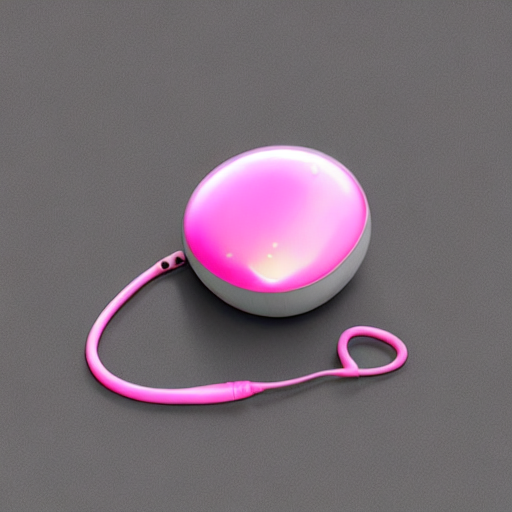

In [13]:
display(image)

  0%|          | 0/30 [00:00<?, ?it/s]

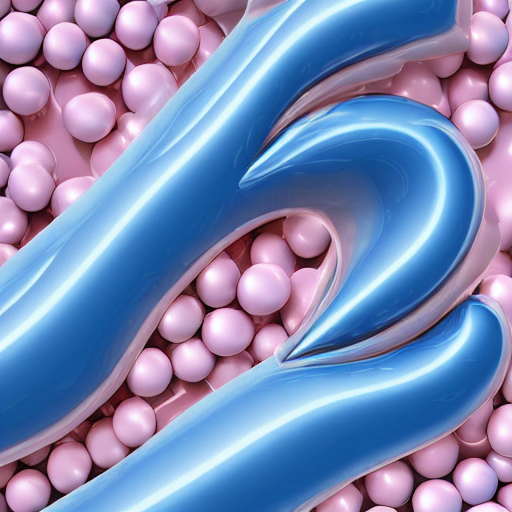

In [14]:
prompt = "the word 'GLOSSY' in large 3d letters, bubblestyle, inflated like balloon typography, high gloss, pastel blue color, warm internal glow, studio lighting, depth of field"

image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
image.save("bubble_result_2.png")
display(image)

  0%|          | 0/30 [00:00<?, ?it/s]

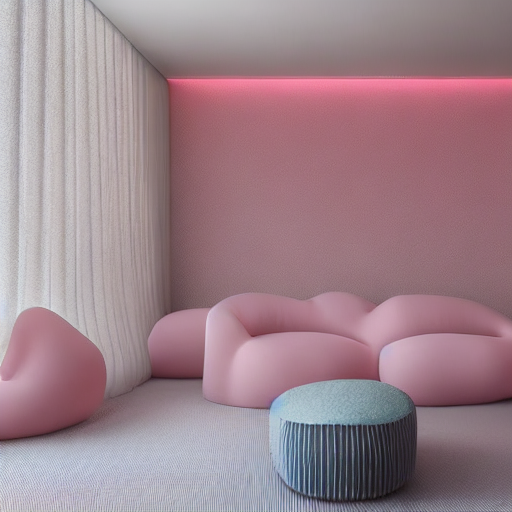

In [16]:
prompt = "interior of a dreamlike living room, furniture made of big inflated soft pillows, bubblestyle design, translucent walls, soft diffused lighting, white and pastel pink palette, 3d render"
image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
image.save("bubble_result_3.png")
display(image)

  0%|          | 0/30 [00:00<?, ?it/s]

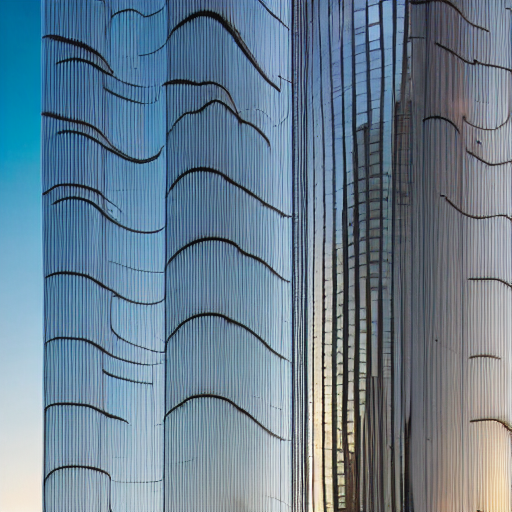

In [17]:
prompt = "a massive conceptual skyscraper in a modern city, designed in bubblestyle, translucent organic facade, looking like big puffy cells, reflecting sunset light, futuristic architecture, 8k"
image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
image.save("bubble_result_4.png")
display(image)

## Вывод
Получились очень красивые и необычные генерации! Они стилизованы весьма неплохо, если учитывать, что моделька маленькая и имела мало итераций для обучения. Также, стоит помнить о собранном датасете, его всегда можно дорабатывать, собрать побольше примеров стиля